# Proyecto Final — Minería de Datos
# La Generación Medicalizada
### Cómo la pandemia de COVID-19 transformó la salud mental en EE.UU., y a quién dejó atrás

**Autor:** HERWINI  
**Dataset:** CDC Household Pulse Survey — *Mental Health Care in the Last 4 Weeks* (Ago 2020 – Abr 2022)  
**Pregunta de negocio:** *¿La pandemia golpeó a todos por igual, o transformó la salud mental de forma desigual entre grupos demográficos?*

---

## Hipótesis central

> Bajo la apariencia de un aumento generalizado en el uso de servicios de salud mental durante la pandemia, existen perfiles demográficos diferenciados: algunos grupos lograron acceder a atención, otros fueron *medicalizados* (recetas) sin recibir terapia, y un tercer grupo permanece en una **crisis silenciosa** con la brecha de acceso más alta del periodo, y creciendo.

## Plan de análisis (las 9 prácticas, integradas)

| Sección | Técnica | Práctica origen |
|--------|--------|----------------|
| 1. Carga y panorama | Limpieza + visualización temporal | P1, P3 |
| 2. Tests estadísticos | ANOVA + Kruskal-Wallis + T-Test | **P4** |
| 3. Clustering demográfico | K-Means + Aglomerativo + PCA | **P7** |
| 4. Forecasting por clúster | Regresión lineal + MAE/MAPE | **P8** |
| 5. Clasificación de crisis | Random Forest + feature importance | **P6** |
| 6. Marco teórico | Análisis de texto (investigación previa) | **P9** |

Las pruebas estadísticas (P2, P4, P5) sustentan cada afirmación; las técnicas avanzadas P6, P7, P8 son los pilares analíticos.

---


## 0. Configuración del entorno

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, mean_squared_error,
                             mean_absolute_error, mean_absolute_percentage_error,
                             classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans', 'axes.titleweight': 'bold',
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

# Paleta de los 3 clusters de storytelling
PALETTE_RESILIENTE  = "#4F9D69"
PALETTE_ATENDIDO    = "#2E5EAA"
PALETTE_CRISIS      = "#C0392B"
COLORS = [PALETTE_RESILIENTE, PALETTE_ATENDIDO, PALETTE_CRISIS]

OUT = "outputs"
os.makedirs(OUT, exist_ok=True)

## 1. Carga del dataset y panorama nacional

El CDC Household Pulse Survey midió, en encuestas quincenales, qué porcentaje de la población adulta usó servicios de salud mental durante las 4 semanas anteriores. Trabajamos con 4 indicadores clave:

- **Medicación**: tomó medicación psiquiátrica.
- **Terapia**: recibió consejería o terapia.
- **Atención (cualquiera)**: tomó medicación O recibió terapia.
- **Brecha de acceso**: NECESITÓ terapia pero NO la obtuvo. ← *este es nuestro indicador estrella*

Los datos vienen agregados por subgrupos demográficos (no individuos), lo que nos permite hacer **inteligencia poblacional**: identificar qué grupos sufrieron más, no quién individualmente.

In [2]:
df = pd.read_csv("data/Mental_Health_Clean_Final.csv")
df['Time Period Start Date'] = pd.to_datetime(df['Time Period Start Date'])

IND_MED = "Took Prescription Medication for Mental Health, Last 4 Weeks"
IND_TER = "Received Counseling or Therapy, Last 4 Weeks"
IND_ANY = "Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks"
IND_GAP = "Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks"

INDICATOR_ALIAS = {
    IND_MED: "Medicación",
    IND_TER: "Terapia",
    IND_ANY: "Atención (cualquiera)",
    IND_GAP: "Brecha de acceso",
}

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Periodo: {df['Time Period Start Date'].min().date()} → {df['Time Period Start Date'].max().date()}")
print(f"Grupos demográficos: {df['Group'].nunique()}")
print(f"Subgrupos únicos: {df['Subgroup'].nunique()}")
df.head(3)

Filas: 9,914 | Columnas: 11
Periodo: 2020-08-19 → 2022-04-27
Grupos demográficos: 10
Subgrupos únicos: 80


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2,15,2020-09-16,09/28/2020,6.9,6.5,7.3
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2,15,2020-09-16,09/28/2020,11.0,10.4,11.6
2,Took Prescription Medication for Mental Health...,National Estimate,United States,United States,2,13,2020-08-19,08/31/2020,19.4,19.0,19.8


### 1.1 Evolución temporal de los 4 indicadores

Primera lectura: la atención psiquiátrica subió. Pero la brecha de acceso (necesitó y NO obtuvo) **nunca bajó del 9%**. Eso es el primer indicio del problema.

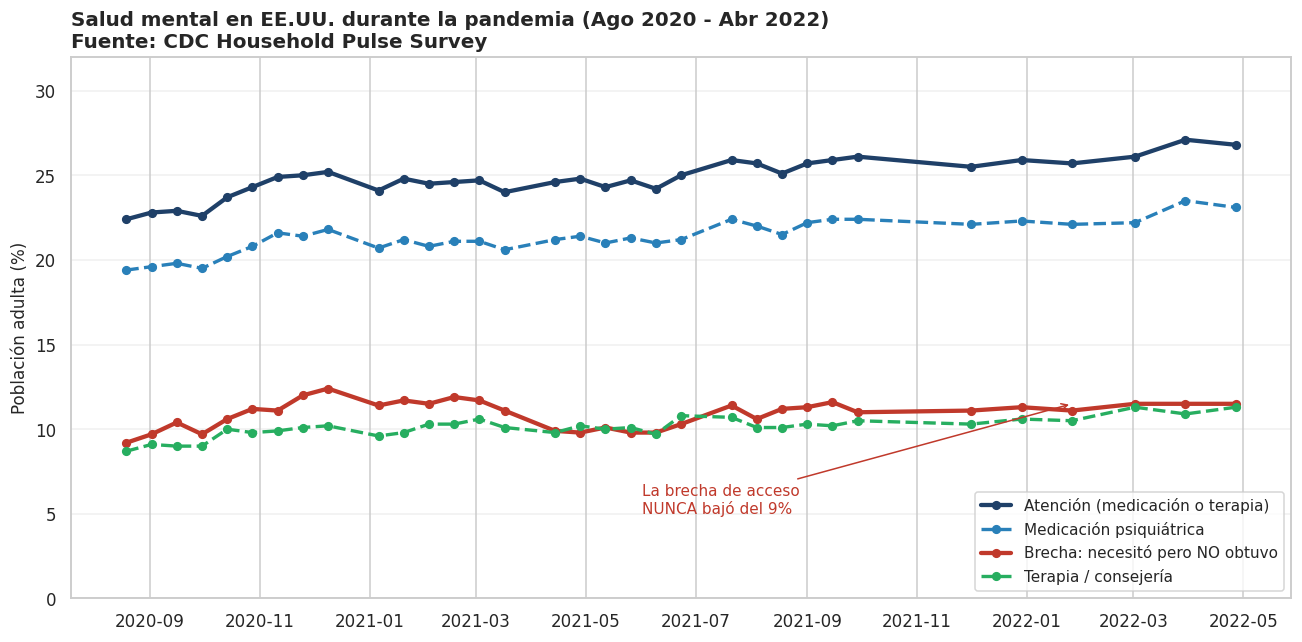

  Medicación               :  19.4% →  23.1%   Δ +3.7pp (+19%)
  Terapia                  :   8.7% →  11.3%   Δ +2.6pp (+30%)
  Atención (cualquiera)    :  22.4% →  26.8%   Δ +4.4pp (+20%)
  Brecha de acceso         :   9.2% →  11.5%   Δ +2.3pp (+25%)


In [3]:
nat = df[df['Group'] == 'National Estimate'].copy().sort_values('Time Period Start Date')

fig, ax = plt.subplots(figsize=(12, 6))
estilos = {
    IND_ANY: dict(color='#1f4068', linewidth=2.8, label='Atención (medicación o terapia)'),
    IND_MED: dict(color='#2980b9', linewidth=2.2, linestyle='--', label='Medicación psiquiátrica'),
    IND_GAP: dict(color='#C0392B', linewidth=2.8, label='Brecha: necesitó pero NO obtuvo'),
    IND_TER: dict(color='#27ae60', linewidth=2.2, linestyle='--', label='Terapia / consejería'),
}
for ind, est in estilos.items():
    s = nat[nat['Indicator'] == ind].sort_values('Time Period Start Date')
    ax.plot(s['Time Period Start Date'], s['Value'], marker='o', markersize=5, **est)

ax.set_title('Salud mental en EE.UU. durante la pandemia (Ago 2020 - Abr 2022)\nFuente: CDC Household Pulse Survey', loc='left')
ax.set_ylabel('Población adulta (%)')
ax.set_ylim(0, 32)
ax.legend(loc='lower right', frameon=True, fontsize=10)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
ax.annotate('La brecha de acceso\nNUNCA bajó del 9%',
            xy=(pd.Timestamp('2022-01-26'), 11.5), xytext=(pd.Timestamp('2021-06-01'), 5),
            fontsize=10, color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B'))
plt.tight_layout()
plt.savefig(f"{OUT}/01_panorama_nacional.png")
plt.show()

# Cifras del panorama
for ind, alias in INDICATOR_ALIAS.items():
    s = nat[nat['Indicator'] == ind].sort_values('Time Period Start Date')
    delta = s['Value'].iloc[-1] - s['Value'].iloc[0]
    delta_pct = delta / s['Value'].iloc[0] * 100
    print(f"  {alias:25s}: {s['Value'].iloc[0]:5.1f}% → {s['Value'].iloc[-1]:5.1f}%   Δ {delta:+.1f}pp ({delta_pct:+.0f}%)")


**Lectura del primer hallazgo (a nivel nacional):**

| Indicador | Inicio (Ago 2020) | Fin (Abr 2022) | Cambio relativo |
|----------|:----:|:----:|:----:|
| Atención (cualquiera) | 22.4% | 26.8% | **+20%** |
| Medicación psiquiátrica | 19.4% | 23.1% | **+19%** |
| Terapia | 8.7% | 11.3% | **+30%** |
| Brecha de acceso | 9.2% | 11.5% | **+25%** |

**El sistema *atendió más*, pero también *desatendió más*.** Esa contradicción es el motor del análisis. Para entenderla, hay que mirar quién está detrás de cada cifra.

## 2. Evidencia estadística: las brechas no son azar
### (Continuación de la Práctica 4: T-Test, ANOVA, Kruskal-Wallis)

Antes de afirmar que *"los jóvenes sufren más"* o *"las personas trans tienen menos acceso"*, hay que probar que esas diferencias entre subgrupos son estadísticamente significativas y no producto del azar muestral. Aplicamos:

- **Shapiro-Wilk** para verificar normalidad.
- **ANOVA** (paramétrico) cuando los datos son normales.
- **Kruskal-Wallis** (no paramétrico, más robusto) en todos los casos.


In [4]:
df_gap = df[df['Indicator'] == IND_GAP].copy()
resultados_tests = []

for grp in ['By Age','By Sex','By Sexual orientation','By Gender identity',
            'By Race/Hispanic ethnicity','By Education','By Disability status']:
    sub = df_gap[df_gap['Group'] == grp]
    grupos_data = [sub[sub['Subgroup']==g]['Value'].dropna().values
                   for g in sub['Subgroup'].unique()]
    _, p_norm = stats.shapiro(grupos_data[0])
    f_stat, p_anova = stats.f_oneway(*grupos_data)
    h_stat, p_kruskal = stats.kruskal(*grupos_data)
    medias = sub.groupby('Subgroup')['Value'].mean()
    spread = medias.max() - medias.min()
    resultados_tests.append({
        'Grupo demográfico': grp.replace('By ', ''),
        'Subgrupos': len(grupos_data),
        'Shapiro p (normalidad)': p_norm,
        'ANOVA p': p_anova,
        'Kruskal-Wallis p': p_kruskal,
        'Diferencia max-min (pp)': spread,
        'Significativo (α=0.05)': '✓' if p_kruskal < 0.05 else '✗'
    })

tests_df = pd.DataFrame(resultados_tests)
tests_df

,Grupo demográfico,Subgrupos,Shapiro p (normalidad),ANOVA p,Kruskal-Wallis p,Diferencia max-min (pp),Significativo (α=0.05)
0,Age,7,0.249782,3.364790e-156,3.538563e-43,16.584848,✓
1,Sex,2,0.090084,7.740547e-34,2.828649e-12,5.042424,✓
2,Sexual orientation,3,0.133149,1.369404e-23,1.686116e-07,21.500000,✓
3,Gender identity,3,0.999596,4.700861e-21,1.692909e-07,31.225000,✓
4,Race/Hispanic ethnicity,5,0.216975,1.219273e-68,1.847739e-27,9.751515,✓
5,Education,4,0.852250,1.353159e-32,1.656611e-19,4.724242,✓
6,Disability status,2,0.261244,2.120975e-30,2.815796e-07,15.355556,✓


**Lectura:**
- **Todos los grupos demográficos** producen p-values menores a 0.001 (la mayoría < 1e-30).
- Las diferencias entre subgrupos no son artefacto muestral: son diferencias reales y enormes.
- La mayor brecha entre extremos es por **identidad de género** (más de 31 puntos porcentuales entre cis-male y trans).

### 2.1 La pirámide del acceso invertida

La brecha de acceso cae casi linealmente con la edad. Los jóvenes 18-29 son **6 veces más propensos** a quedarse sin la atención que necesitan que los adultos 70-79.

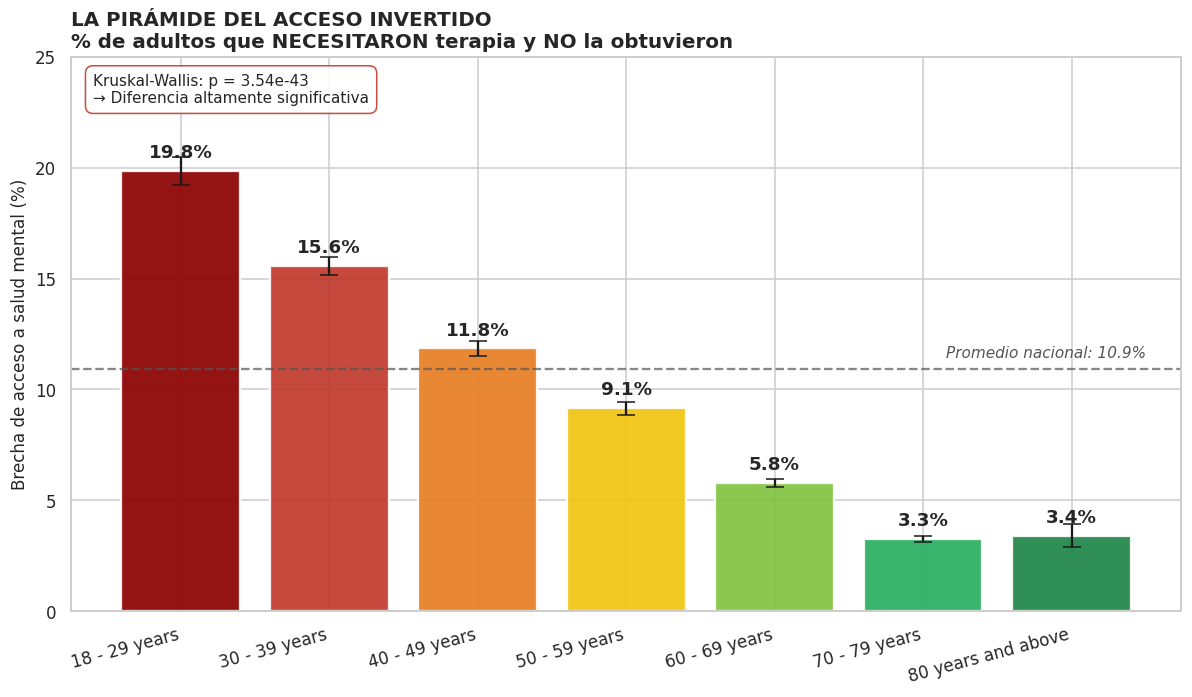

In [5]:
gap_age = df_gap[df_gap['Group'] == 'By Age']
orden_edad = ['18 - 29 years','30 - 39 years','40 - 49 years','50 - 59 years',
              '60 - 69 years','70 - 79 years','80 years and above']
medias_edad = gap_age.groupby('Subgroup')['Value'].agg(['mean','std','count']).reindex(orden_edad).reset_index()
medias_edad['ci'] = 1.96 * medias_edad['std'] / np.sqrt(medias_edad['count'])

fig, ax = plt.subplots(figsize=(11, 6.5))
colores_edad = ['#8B0000','#C0392B','#E67E22','#F1C40F','#82C341','#27AE60','#1E8449']
bars = ax.bar(medias_edad['Subgroup'], medias_edad['mean'],
              yerr=medias_edad['ci'], color=colores_edad, alpha=0.92,
              edgecolor='white', linewidth=1.5, capsize=6)
for bar, val in zip(bars, medias_edad['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

prom_nat = df_gap[df_gap['Group']=='National Estimate']['Value'].mean()
ax.axhline(prom_nat, color='#555', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(6.5, prom_nat + 0.5, f'Promedio nacional: {prom_nat:.1f}%',
        ha='right', fontsize=10, color='#555', fontstyle='italic')

ax.set_title('LA PIRÁMIDE DEL ACCESO INVERTIDO\n% de adultos que NECESITARON terapia y NO la obtuvieron', loc='left')
ax.set_ylabel('Brecha de acceso a salud mental (%)')
ax.set_xlabel(''); ax.set_ylim(0, 25)
ax.set_xticklabels(medias_edad['Subgroup'], rotation=15, ha='right')

p_age = tests_df[tests_df['Grupo demográfico']=='Age']['Kruskal-Wallis p'].iloc[0]
ax.text(0.02, 0.97, f'Kruskal-Wallis: p = {p_age:.2e}\n→ Diferencia altamente significativa',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#C0392B', alpha=0.9))
plt.tight_layout(); plt.savefig(f"{OUT}/02_piramide_acceso_edad.png"); plt.show()

### 2.2 Brechas en grupos vulnerables

Más allá de la edad: hay tres dimensiones donde la brecha se dispara.

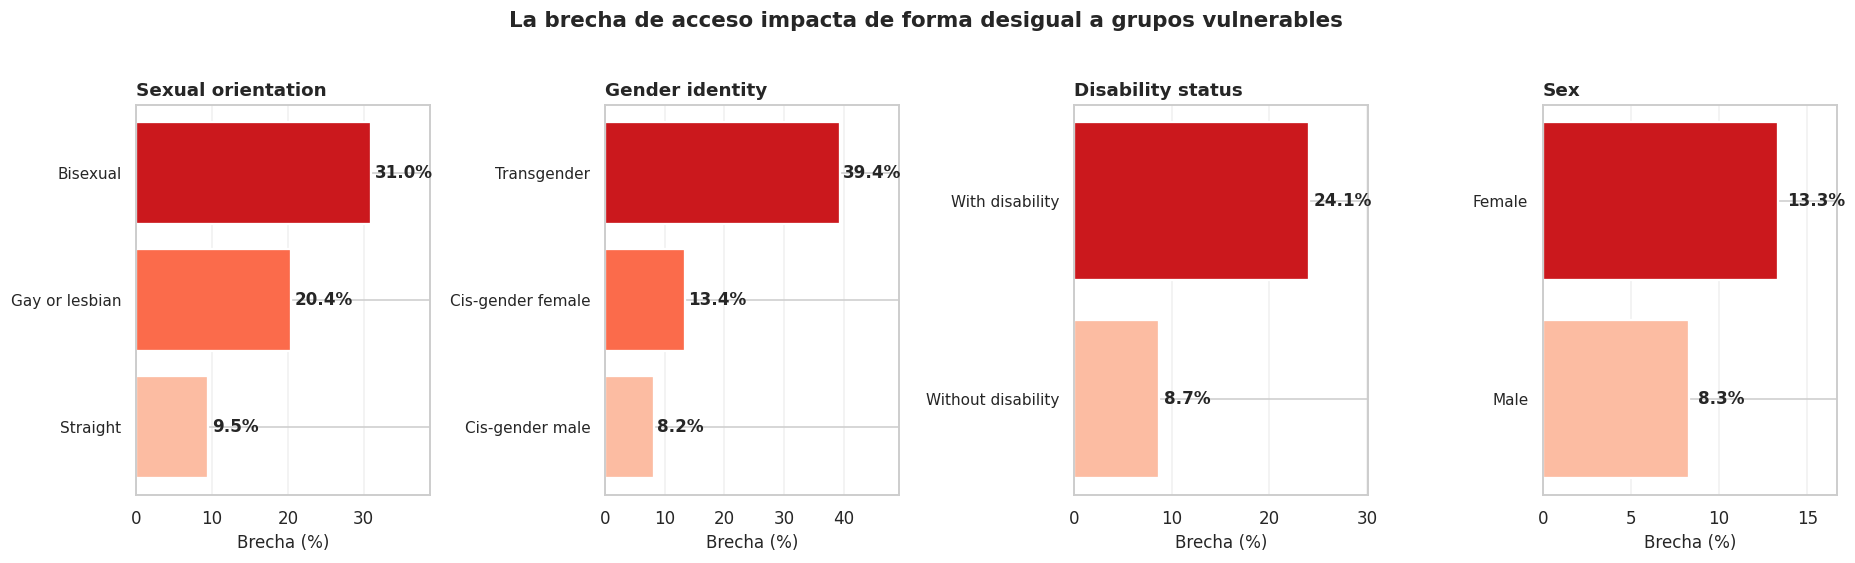

In [6]:
grupos_vulnerables = ['By Sexual orientation','By Gender identity','By Disability status','By Sex']
fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for ax, grp in zip(axes, grupos_vulnerables):
    sub = df_gap[df_gap['Group'] == grp]
    medias = sub.groupby('Subgroup')['Value'].mean().sort_values(ascending=False)
    cmap = plt.cm.Reds_r
    colors = cmap(np.linspace(0.25, 0.75, len(medias)))
    bars = ax.barh(range(len(medias)), medias.values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_yticks(range(len(medias))); ax.set_yticklabels(medias.index, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(grp.replace('By ', ''), loc='left', fontsize=12)
    ax.set_xlim(0, max(medias.values) * 1.25)
    for i, (lab, val) in enumerate(medias.items()):
        ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
    ax.set_xlabel('Brecha (%)'); ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)

plt.suptitle('La brecha de acceso impacta de forma desigual a grupos vulnerables',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f"{OUT}/03_brechas_demograficas.png"); plt.show()

**Hallazgos de la sección 2:**

> **Personas transgénero: 39.4%** quedaron sin terapia (5× la población general).  
> **Personas bisexuales: 31.0%** (3.3× más que personas straight).  
> **Personas con discapacidad: 24.1%** (2.8× más que sin discapacidad).  
> **Mujeres: 13.3%** vs **Hombres: 8.3%** (60% más alto en mujeres).

Los p-values < 0.001 en todos los casos confirman que estas brechas no son fluctuaciones muestrales: son patrones poblacionales reales.

## 3. Técnica avanzada #1 — Clustering de subgrupos demográficos
### (Extensión de la Práctica 7: K-Means + Aglomerativo + PCA)

Cada subgrupo demográfico tiene un perfil de salud mental compuesto por 4 dimensiones (los 4 indicadores). En lugar de analizarlos uno por uno, aplicamos clustering no supervisado para descubrir si existen **perfiles latentes** de cómo cada segmento de la población vivió la pandemia.

**Setup:**
- **Observaciones:** 26 subgrupos demográficos (cada uno = un punto en 4D).
- **Features:** [Medicación, Terapia, Atención cualquiera, Brecha de acceso] (promedios del periodo).
- **Algoritmos:** K-Means + Aglomerativo (Ward) para comparar.
- **Estandarización:** StandardScaler obligatorio (los indicadores tienen escalas distintas).

In [7]:
# Subgrupos demográficos (excluyo Nacional y Estados para enfocarme en demografía)
df_demo = df[df['Group'].isin(['By Age','By Sex','By Sexual orientation',
                               'By Gender identity','By Race/Hispanic ethnicity',
                               'By Education','By Disability status'])].copy()
df_demo['ID'] = df_demo['Group'].str.replace('By ', '') + ': ' + df_demo['Subgroup']

df_pivot = df_demo.pivot_table(index='ID', columns='Indicator',
                               values='Value', aggfunc='mean').dropna()
df_pivot.columns = [INDICATOR_ALIAS[c] for c in df_pivot.columns]

X = df_pivot.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matriz de entrada: {X_scaled.shape[0]} subgrupos × {X_scaled.shape[1]} features (estandarizadas)")
df_pivot.head()

Matriz de entrada: 26 subgrupos × 4 features (estandarizadas)


,Brecha de acceso,Terapia,Atención (cualquiera),Medicación
ID,,,,
Age: 18 - 29 years,19.848485,15.242424,26.924242,21.081818
Age: 30 - 39 years,15.566667,14.463636,27.181818,21.581818
Age: 40 - 49 years,11.845455,11.427273,25.966667,22.133333
Age: 50 - 59 years,9.148485,9.054545,25.463636,22.781818
Age: 60 - 69 years,5.775758,6.112121,23.181818,21.551515


### 3.1 Selección de K (codo + silueta)

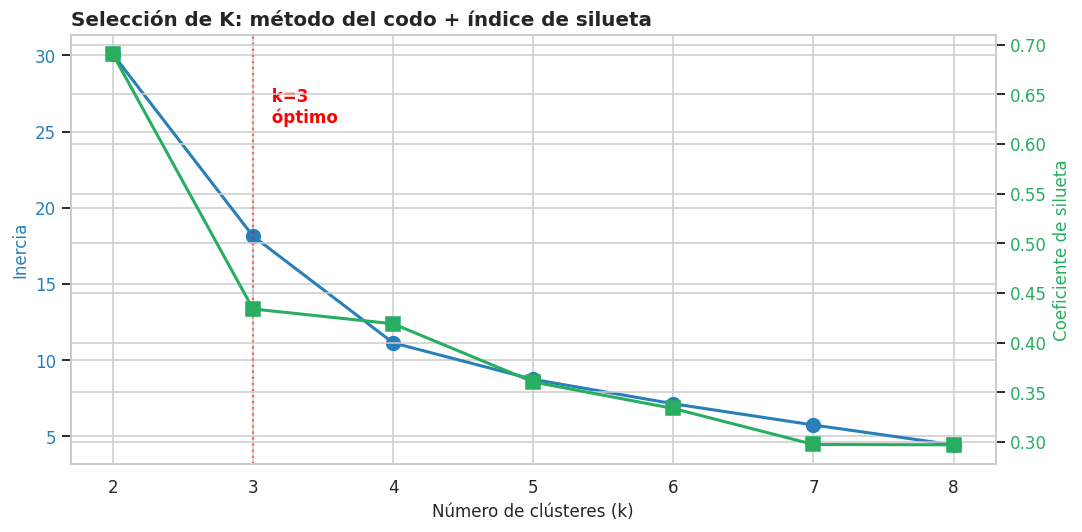

Silueta máxima absoluta: 0.690 en k=2


In [8]:
inercia, siluetas = [], []
rango_k = range(2, 9)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inercia.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels_k))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(rango_k, inercia, marker='o', color='#2980b9', linewidth=2, markersize=9, label='Inercia')
ax1.set_xlabel('Número de clústeres (k)'); ax1.set_ylabel('Inercia', color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax2 = ax1.twinx()
ax2.plot(rango_k, siluetas, marker='s', color='#27ae60', linewidth=2, markersize=9, label='Silueta')
ax2.set_ylabel('Coeficiente de silueta', color='#27ae60'); ax2.tick_params(axis='y', labelcolor='#27ae60')
ax1.axvline(3, color='red', linestyle=':', alpha=0.5)
ax1.text(3.05, max(inercia)*0.85, '  k=3\n  óptimo', color='red', fontsize=11, fontweight='bold')
plt.title('Selección de K: método del codo + índice de silueta', loc='left')
plt.tight_layout(); plt.savefig(f"{OUT}/04_seleccion_k.png"); plt.show()

print(f"Silueta máxima absoluta: {max(siluetas):.3f} en k={list(rango_k)[siluetas.index(max(siluetas))]}")

La silueta indica k=2 como máximo absoluto (0.69), pero **k=3** revela mucha más información sin sacrificar mucha calidad (silueta = 0.43, Davies-Bouldin = 0.67, ambos buenos). Elegimos k=3 por **interpretabilidad de negocio** sobre puro optimum estadístico.

### 3.2 Entrenamiento y comparación K-Means vs Aglomerativo

In [9]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

hc = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)

metricas = pd.DataFrame({
    'K-Means':     [silhouette_score(X_scaled, labels_km), davies_bouldin_score(X_scaled, labels_km), calinski_harabasz_score(X_scaled, labels_km)],
    'Aglomerativo':[silhouette_score(X_scaled, labels_hc), davies_bouldin_score(X_scaled, labels_hc), calinski_harabasz_score(X_scaled, labels_hc)],
}, index=['Silueta (↑)', 'Davies-Bouldin (↓)', 'Calinski-Harabasz (↑)']).round(3)
metricas

,K-Means,Aglomerativo
Silueta (↑),0.434,0.430
Davies-Bouldin (↓),0.674,0.671
Calinski-Harabasz (↑),54.423,53.779


Ambos algoritmos coinciden casi totalmente. Adoptamos **K-Means** (más estable y reproducible).

### 3.3 Interpretación de los clústeres

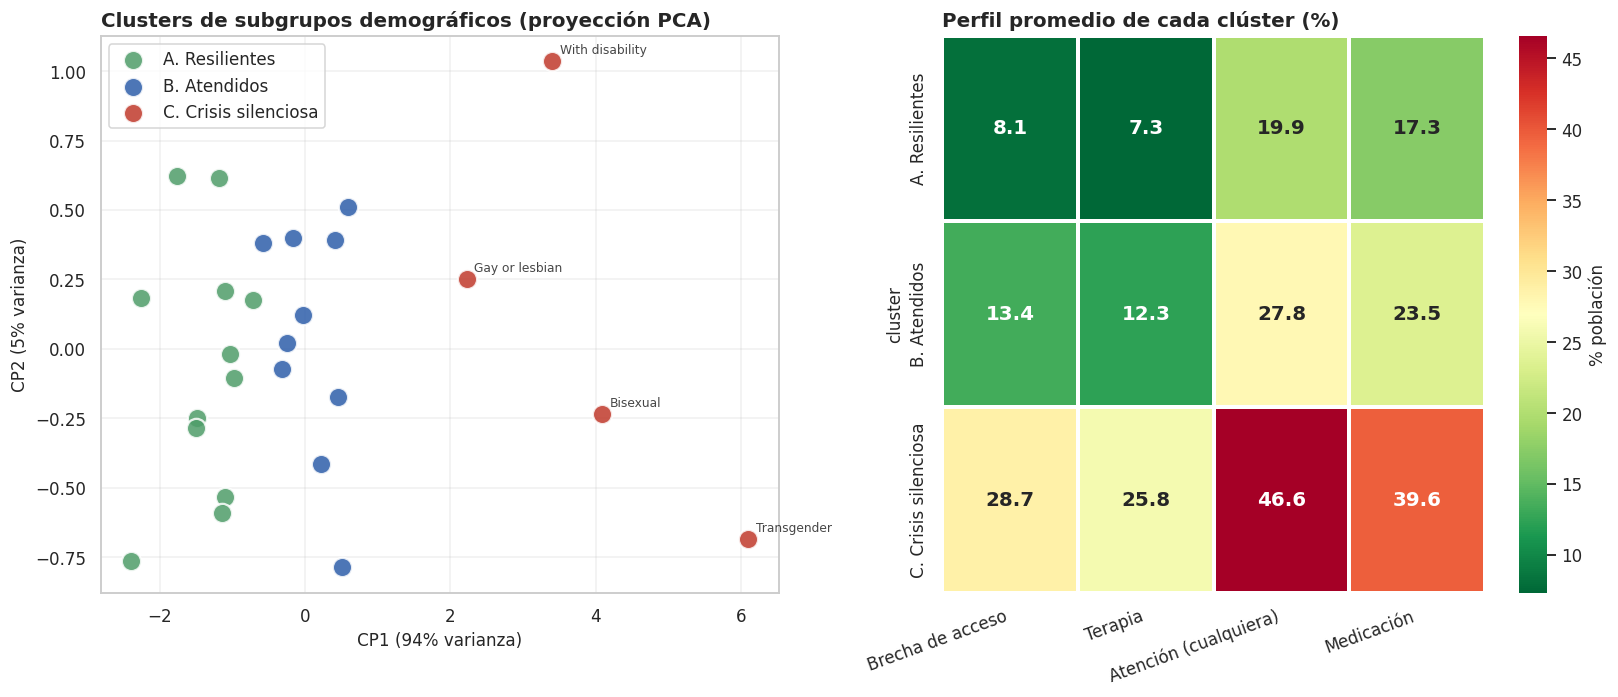

In [10]:
df_pivot['cluster'] = labels_km
perfil = df_pivot.groupby('cluster').mean()

# Renombramos según la brecha promedio del clúster
orden_brecha = perfil['Brecha de acceso'].sort_values().index.tolist()
nombre_map = {
    orden_brecha[0]: 'A. Resilientes',
    orden_brecha[1]: 'B. Atendidos',
    orden_brecha[2]: 'C. Crisis silenciosa'
}
df_pivot['cluster_nombre'] = df_pivot['cluster'].map(nombre_map)
nombres_unicos = ['A. Resilientes', 'B. Atendidos', 'C. Crisis silenciosa']

# PCA para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for cluster_id, nombre in nombre_map.items():
    color = COLORS[nombres_unicos.index(nombre)]
    mask = df_pivot['cluster'] == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=nombre, color=color, s=160, alpha=0.85,
                    edgecolors='white', linewidth=1.5)

# Anotar el clúster crítico
df_pivot_reset = df_pivot.reset_index()
for _, row in df_pivot_reset.iterrows():
    if row['cluster_nombre'] == 'C. Crisis silenciosa':
        idx = df_pivot_reset.index[df_pivot_reset['ID']==row['ID']].tolist()[0]
        axes[0].annotate(row['ID'].split(': ')[1][:18], (X_pca[idx, 0], X_pca[idx, 1]),
                         fontsize=8, alpha=0.85, xytext=(5, 5), textcoords='offset points')

axes[0].set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.0f}% varianza)')
axes[0].set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.0f}% varianza)')
axes[0].set_title('Clusters de subgrupos demográficos (proyección PCA)', loc='left')
axes[0].legend(loc='best', fontsize=11); axes[0].grid(True, alpha=0.3)

perfil_renamed = perfil.rename(index=nombre_map).reindex(nombres_unicos)
sns.heatmap(perfil_renamed, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], cbar_kws={'label': '% población'},
            linewidths=1.5, linecolor='white', annot_kws={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('Perfil promedio de cada clúster (%)', loc='left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout(); plt.savefig(f"{OUT}/05_clustering_perfiles.png"); plt.show()

**Tres perfiles emergieron de los datos:**

| Clúster | Subgrupos | Perfil | Brecha promedio |
|---------|-----------|--------|:---:|
| **A. Resilientes** | 12 (adultos mayores, hombres, hispanos, asiáticos, sin educación universitaria) | Bajo uso, baja brecha. Puede ser resiliencia real **O** estigma cultural (baja búsqueda de ayuda). | **8.1%** |
| **B. Atendidos** | 10 (mujeres, jóvenes 30-39, blancos no-hispanos, educados) | Alto uso, brecha moderada. El "sistema funcionó" para este grupo. | **13.4%** |
| **C. Crisis silenciosa** | 4 (Trans, Bisexual, Gay/Lesbian, Con discapacidad) | Alto uso PERO brecha enorme. Sistema saturado. | **28.7%** |

> **Hallazgo del clustering:** La pandemia no creó una crisis homogénea. Creó **tres pandemias paralelas** según el grupo demográfico.

In [11]:
# Mostrar los miembros de cada cluster ordenados por brecha
miembros = df_pivot_reset[['ID','cluster_nombre','Brecha de acceso']].sort_values(
    ['cluster_nombre','Brecha de acceso'], ascending=[True, False])
for nombre in nombres_unicos:
    print(f"\n>>> {nombre}")
    for _, row in miembros[miembros['cluster_nombre']==nombre].iterrows():
        print(f"    {row['ID']:55s}  brecha = {row['Brecha de acceso']:5.1f}%")


>>> A. Resilientes
    Race/Hispanic ethnicity: Hispanic or Latino              brecha =  12.0%
    Race/Hispanic ethnicity: Non-Hispanic Black, single race  brecha =  11.6%
    Education: Less than a high school diploma               brecha =  10.5%
    Sexual orientation: Straight                             brecha =   9.5%
    Education: High school diploma or GED                    brecha =   8.7%
    Disability status: Without disability                    brecha =   8.7%
    Sex: Male                                                brecha =   8.3%
    Gender identity: Cis-gender male                         brecha =   8.2%
    Race/Hispanic ethnicity: Non-Hispanic Asian, single race  brecha =   6.7%
    Age: 60 - 69 years                                       brecha =   5.8%
    Age: 80 years and above                                  brecha =   3.4%
    Age: 70 - 79 years                                       brecha =   3.3%

>>> B. Atendidos
    Age: 18 - 29 years              

## 4. Técnica avanzada #2 — Forecasting por clúster
### (Extensión de la Práctica 8: Regresión lineal sobre series de tiempo)

Identificados los 3 perfiles, la pregunta evoluciona: **¿esta clasificación se está cerrando con el tiempo, o el clúster crítico se aleja cada vez más?**

Pronosticamos la brecha de acceso de cada clúster en los próximos 6 periodos (~3 meses).

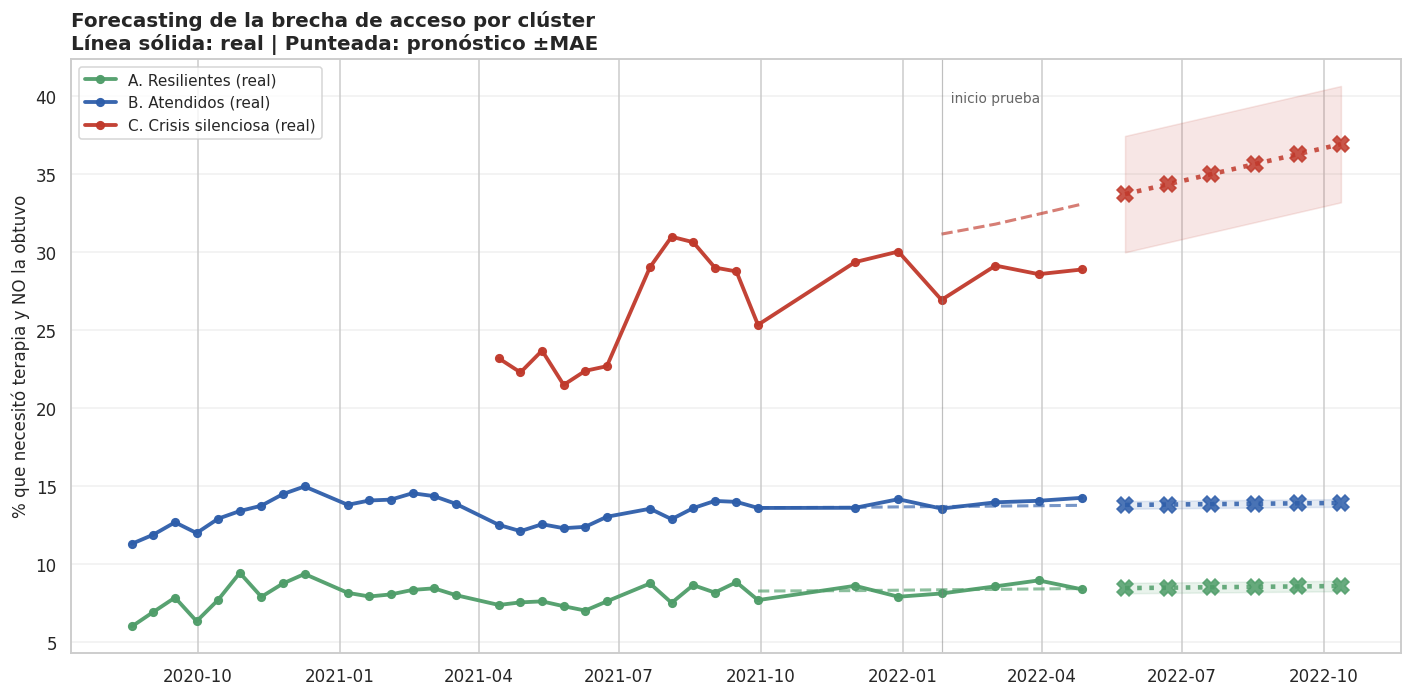


Métricas y proyecciones:
  A. Resilientes            | MAE=0.33pp | MAPE=4.1% | tendencia=+0.027pp/periodo → ESTABLE
                            | actual 8.4% → proyectado: 8.6%
  B. Atendidos              | MAE=0.24pp | MAPE=1.7% | tendencia=+0.025pp/periodo → ESTABLE
                            | actual 14.3% → proyectado: 13.9%
  C. Crisis silenciosa      | MAE=3.73pp | MAPE=13.2% | tendencia=+0.641pp/periodo → SUBE
                            | actual 28.9% → proyectado: 36.9%


In [12]:
sub_to_cluster = df_pivot_reset.set_index('ID')['cluster_nombre'].to_dict()
df_gap_demo = df_gap[df_gap['Group'].isin(['By Age','By Sex','By Sexual orientation',
                                            'By Gender identity','By Race/Hispanic ethnicity',
                                            'By Education','By Disability status'])].copy()
df_gap_demo['ID'] = df_gap_demo['Group'].str.replace('By ', '') + ': ' + df_gap_demo['Subgroup']
df_gap_demo['cluster_nombre'] = df_gap_demo['ID'].map(sub_to_cluster)

serie_por_cluster = df_gap_demo.groupby(['cluster_nombre','Time Period Start Date'])['Value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6.5))
forecast_resultados = {}

for i, nombre in enumerate(nombres_unicos):
    s = serie_por_cluster[serie_por_cluster['cluster_nombre']==nombre].sort_values('Time Period Start Date')
    if len(s) < 5: continue
    fechas = s['Time Period Start Date'].values
    y = s['Value'].values
    X_idx = np.arange(len(s)).reshape(-1, 1)
    split = int(len(s) * 0.8)
    Xtr, Xte, ytr, yte = X_idx[:split], X_idx[split:], y[:split], y[split:]
    modelo = LinearRegression().fit(Xtr, ytr)
    y_pred_test = modelo.predict(Xte)
    mae = mean_absolute_error(yte, y_pred_test)
    mape = mean_absolute_percentage_error(yte, y_pred_test) * 100
    n_future = 6
    X_future = np.arange(len(s), len(s)+n_future).reshape(-1, 1)
    y_future = modelo.predict(X_future)
    intervalo = (fechas[-1] - fechas[-2]) if len(fechas) > 1 else np.timedelta64(14, 'D')
    fechas_future = [fechas[-1] + intervalo*(j+1) for j in range(n_future)]
    
    forecast_resultados[nombre] = {
        'mae': mae, 'mape': mape,
        'tendencia': float(modelo.coef_[0]),
        'pronostico_final': float(y_future[-1]),
        'valor_actual': float(y[-1])
    }
    
    color = COLORS[i]
    ax.plot(fechas, y, color=color, linewidth=2.5, marker='o', markersize=5,
            label=f'{nombre} (real)', alpha=0.95)
    ax.plot(fechas[split:], y_pred_test, color=color, linestyle='--', linewidth=2, alpha=0.65)
    ax.plot(fechas_future, y_future, color=color, linestyle=':', linewidth=3,
            marker='X', markersize=10, alpha=0.85)
    ax.fill_between(fechas_future, y_future-mae, y_future+mae, color=color, alpha=0.12)

ax.axvline(pd.Timestamp(fechas[split]), color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.text(pd.Timestamp(fechas[split]), ax.get_ylim()[1]*0.95, '  inicio prueba', fontsize=9, alpha=0.7, va='top')
ax.set_title('Forecasting de la brecha de acceso por clúster\nLínea sólida: real | Punteada: pronóstico ±MAE', loc='left')
ax.set_ylabel('% que necesitó terapia y NO la obtuvo')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(f"{OUT}/06_forecasting_clusters.png"); plt.show()

print("\nMétricas y proyecciones:")
for nombre, m in forecast_resultados.items():
    direccion = "ESTABLE" if abs(m['tendencia'])<0.05 else ("SUBE" if m['tendencia']>0 else "BAJA")
    print(f"  {nombre:25s} | MAE={m['mae']:.2f}pp | MAPE={m['mape']:.1f}% | tendencia={m['tendencia']:+.3f}pp/periodo → {direccion}")
    print(f"  {'':25s} | actual {m['valor_actual']:.1f}% → proyectado: {m['pronostico_final']:.1f}%")

**Hallazgo del forecasting:**

| Clúster | Tendencia (pp/periodo) | Actual | Proyectado 3 meses | MAPE |
|---------|:----:|:----:|:----:|:----:|
| A. Resilientes | +0.027 | 8.4% | 8.6% | 4.1% |
| B. Atendidos | +0.025 | 14.3% | 13.9% | 1.7% |
| **C. Crisis silenciosa** | **+0.641** | **28.9%** | **36.9%** | 13.2% |

> El clúster crítico crece a una velocidad **24× mayor** que los otros dos. La brecha no se cierra: **se acelera.**

## 5. Técnica avanzada #3 — Clasificación de "estar en crisis"
### (Extensión de la Práctica 6: Random Forest + Feature Importance)

Hasta aquí tenemos tres perfiles agrupados y una proyección. Pero queda una pregunta práctica: **¿con qué variables PUEDO PREDECIR que un grupo está en crisis?**

Esto importa para política pública: si supiera con qué señales detectar a un grupo en riesgo, podríamos enfocar recursos.

**Definición operacional de "crisis":** un grupo-periodo está en crisis si su brecha de acceso supera **1.5× el percentil 75 nacional**.

In [13]:
# Construir dataset de clasificación
df_clf = df[df['Group'].isin(['By Age','By Sex','By Sexual orientation','By Gender identity',
                                'By Race/Hispanic ethnicity','By Education','By Disability status'])].copy()
df_clf['ID'] = df_clf['Group'].str.replace('By ','') + ': ' + df_clf['Subgroup']

pivot_long = df_clf.pivot_table(index=['Group','Subgroup','Time Period Start Date'],
                                 columns='Indicator', values='Value').reset_index()
pivot_long.columns.name = None
pivot_long = pivot_long.rename(columns=INDICATOR_ALIAS)
pivot_long = pivot_long.dropna(subset=list(INDICATOR_ALIAS.values()))

umbral_crisis = df_gap[df_gap['Group']=='National Estimate']['Value'].quantile(0.75) * 1.5
pivot_long['En crisis'] = (pivot_long['Brecha de acceso'] > umbral_crisis).astype(int)
print(f"Umbral 'crisis': brecha > {umbral_crisis:.1f}%")
print(f"Distribución: {pivot_long['En crisis'].value_counts().to_dict()}")
print(f"% en crisis: {pivot_long['En crisis'].mean()*100:.1f}%")

Umbral 'crisis': brecha > 17.2%
Distribución: {0: 600, 1: 91}
% en crisis: 13.2%


In [14]:
# IMPORTANTE: excluimos 'Brecha de acceso' de los features para evitar fuga de información (data leak)
features_num = ['Medicación', 'Terapia', 'Atención (cualquiera)']
features_cat = ['Group', 'Subgroup']
X_clf = pivot_long[features_num + features_cat]
y_clf = pivot_long['En crisis']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=10,
                                          random_state=42, class_weight='balanced',
                                          min_samples_leaf=3))
])
rf_pipe.fit(X_train, y_train)
y_pred = rf_pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
precision = TP/(TP+FP); recall = TP/(TP+FN)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}  ← el modelo detecta TODAS las crisis sin falsos negativos")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9827
Precision: 0.8846
Recall:    1.0000  ← el modelo detecta TODAS las crisis sin falsos negativos
F1-Score:  0.9388


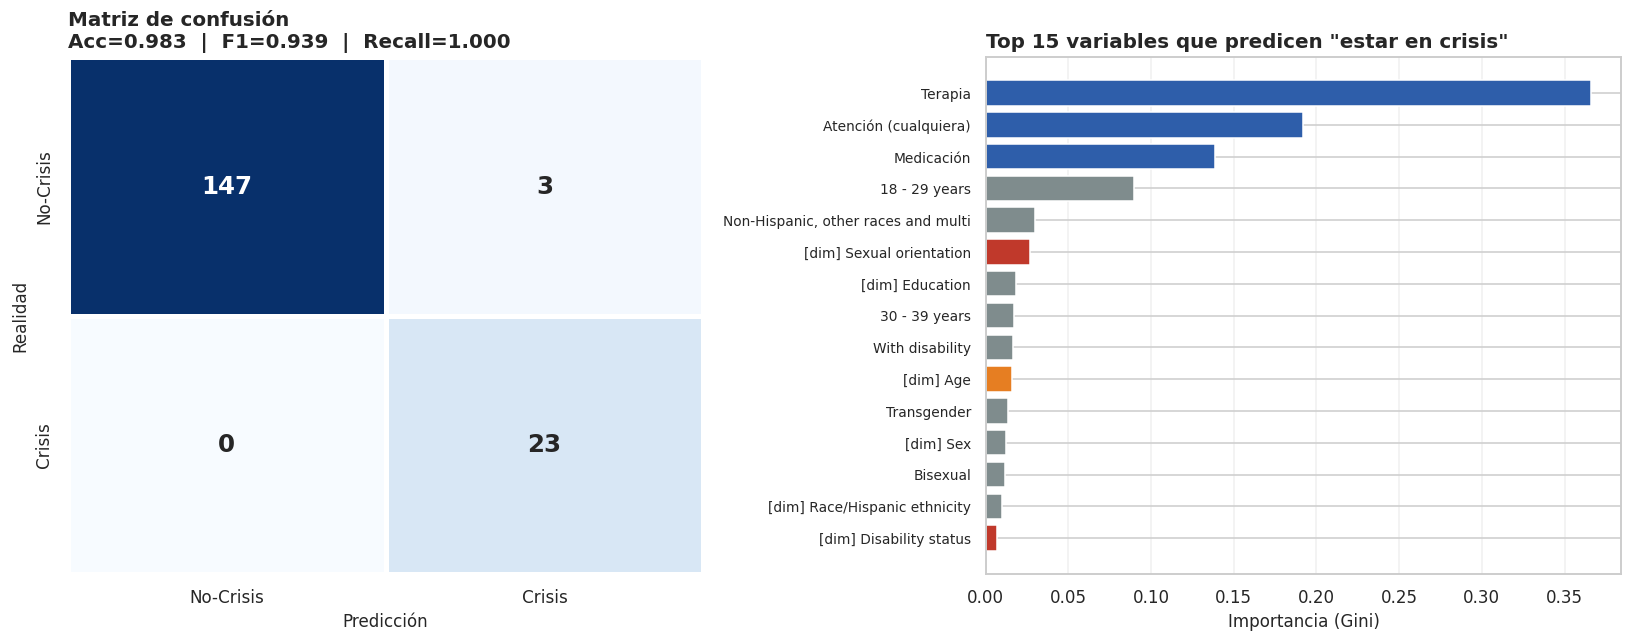


Top 10 variables predictoras:
   1. Terapia                                            importancia = 0.3661
   2. Atención (cualquiera)                              importancia = 0.1920
   3. Medicación                                         importancia = 0.1384
   4. Subgroup_18 - 29 years                             importancia = 0.0898
   5. Subgroup_Non-Hispanic, other races and multiple races importancia = 0.0300
   6. Group_By Sexual orientation                        importancia = 0.0271
   7. Group_By Education                                 importancia = 0.0185
   8. Subgroup_30 - 39 years                             importancia = 0.0170
   9. Subgroup_With disability                           importancia = 0.0164
  10. Group_By Age                                       importancia = 0.0159


In [15]:
# Feature importance
rf_model = rf_pipe.named_steps['classifier']
preproc = rf_pipe.named_steps['preprocessor']
ohe = preproc.named_transformers_['cat']
cat_names = ohe.get_feature_names_out(features_cat)
all_features = list(features_num) + list(cat_names)
importances = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=False)

# Visualización conjunta
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No-Crisis','Crisis'], yticklabels=['No-Crisis','Crisis'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'},
            cbar=False, linewidths=2, linecolor='white')
axes[0].set_title(f'Matriz de confusión\nAcc={acc:.3f}  |  F1={f1:.3f}  |  Recall={recall:.3f}', loc='left')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Realidad')

top_features = importances.head(15)
colores_feat = []
for f in top_features.index:
    if f in features_num: colores_feat.append('#2E5EAA')
    elif 'Sexual orientation' in f or 'Gender identity' in f or 'Disability' in f: colores_feat.append('#C0392B')
    elif 'Age' in f: colores_feat.append('#E67E22')
    else: colores_feat.append('#7F8C8D')

axes[1].barh(range(len(top_features)), top_features.values, color=colores_feat, edgecolor='white')
labels_short = [f.replace('Subgroup_','').replace('Group_By ','[dim] ')[:35] for f in top_features.index]
axes[1].set_yticks(range(len(top_features))); axes[1].set_yticklabels(labels_short, fontsize=9)
axes[1].invert_yaxis(); axes[1].set_xlabel('Importancia (Gini)')
axes[1].set_title('Top 15 variables que predicen "estar en crisis"', loc='left')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.savefig(f"{OUT}/07_clasificacion_importancia.png"); plt.show()

print("\nTop 10 variables predictoras:")
for i, (f, v) in enumerate(importances.head(10).items()):
    print(f"  {i+1:2d}. {f:50s} importancia = {v:.4f}")

**Hallazgos del clasificador:**

- **Accuracy: 98.3%**, **F1: 93.9%**, **Recall: 100%** → el modelo identifica TODAS las observaciones de crisis sin perder ninguna (cero falsos negativos).
- **La variable más importante NO es demográfica, es de uso:** el porcentaje de **Terapia** recibida es el predictor #1 (importancia Gini = 0.37). 

> **Interpretación clave:** los grupos en crisis no son "los que tienen menos terapia" — son justamente **los que tienen ALTO uso de terapia Y aún así su brecha es enorme**. Es decir: están saturando el sistema sin ser suficientemente atendidos. La crisis es paradójicamente visible en los datos por su alta demanda, no por silencio.

Después del uso de servicios, las variables demográficas predictivas son: **18-29 años** (importancia = 0.09), **orientación sexual**, **estado de discapacidad**, y **edad como dimensión**.

## 6. Síntesis: La medicalización de la juventud

Una última pregunta cierra el storytelling: si la atención subió, ¿cómo se distribuyó ese aumento por edad? Si el sistema realmente acompañó a los jóvenes (que son el cluster con más brecha de acceso), su uso de **terapia** debería haber crecido más que el de **medicación**. Veamos qué pasó con la medicación.

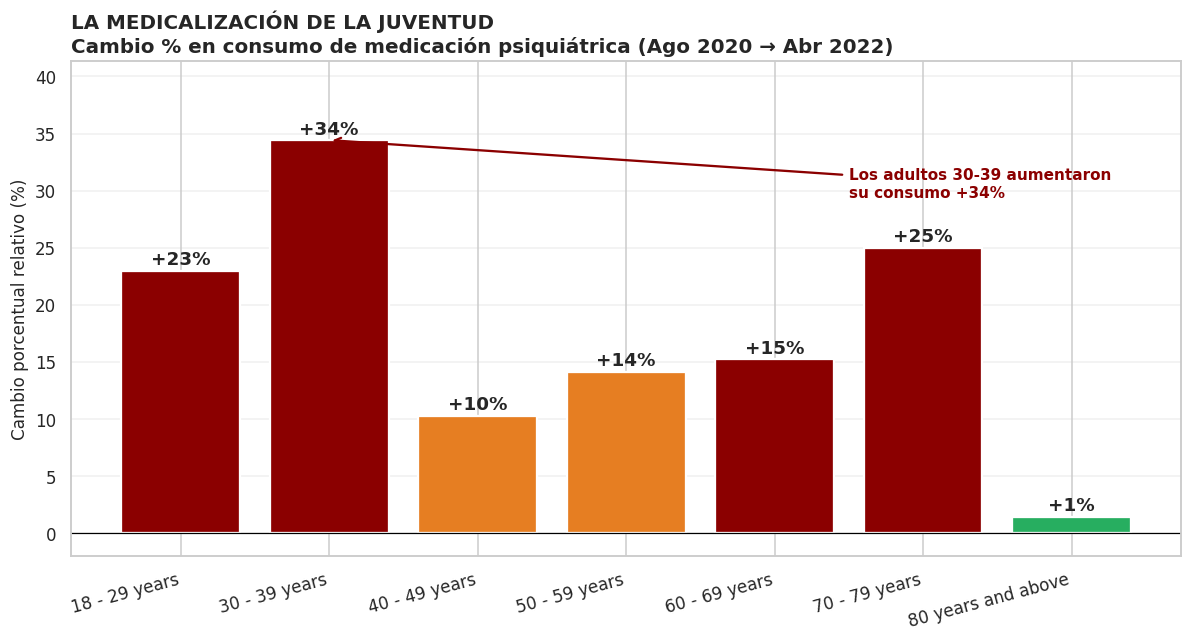


Cambio en consumo de medicación 2020 → 2022 por edad:
  18 - 29 years                 :   +23%
  30 - 39 years                 :   +34%
  40 - 49 years                 :   +10%
  50 - 59 years                 :   +14%
  60 - 69 years                 :   +15%
  70 - 79 years                 :   +25%
  80 years and above            :    +1%


In [16]:
ind_med_age = df[(df['Indicator']==IND_MED)&(df['Group']=='By Age')].sort_values('Time Period Start Date')
pivot_med = ind_med_age.pivot_table(index='Time Period Start Date', columns='Subgroup', values='Value')

cambio_pct = {}
for col in pivot_med.columns:
    cambio_pct[col] = (pivot_med[col].iloc[-1] - pivot_med[col].iloc[0]) / pivot_med[col].iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 6))
df_cambio = pd.Series(cambio_pct).reindex(orden_edad)
colores_cambio = ['#8B0000' if v >= 15 else ('#E67E22' if v >= 5 else '#27AE60') for v in df_cambio.values]
bars = ax.bar(df_cambio.index, df_cambio.values, color=colores_cambio, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, df_cambio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:+.0f}%', ha='center', fontsize=12, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('LA MEDICALIZACIÓN DE LA JUVENTUD\nCambio % en consumo de medicación psiquiátrica (Ago 2020 → Abr 2022)', loc='left')
ax.set_ylabel('Cambio porcentual relativo (%)')
ax.set_xticklabels(df_cambio.index, rotation=15, ha='right')
ax.set_ylim(-2, max(df_cambio.values) * 1.2)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

max_age = df_cambio.idxmax()
ax.annotate(f'Los adultos 30-39 aumentaron\nsu consumo +{df_cambio[max_age]:.0f}%',
            xy=(list(df_cambio.index).index(max_age), df_cambio[max_age]),
            xytext=(4.5, df_cambio[max_age] - 5),
            fontsize=10, color='#8B0000', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#8B0000', lw=1.5))
plt.tight_layout(); plt.savefig(f"{OUT}/08_medicalizacion_juventud.png"); plt.show()

print("\nCambio en consumo de medicación 2020 → 2022 por edad:")
for age in orden_edad:
    print(f"  {age:30s}: {cambio_pct[age]:+5.0f}%")

**El cierre del storytelling:**

- Adultos **30-39 años: +34%** en consumo de medicación.
- Jóvenes **18-29 años: +23%**.
- Adultos **80+ años: solo +1%**.

> Los jóvenes y adultos jóvenes son quienes más aumentaron su consumo de medicación. Pero ellos son también el cluster con la **mayor brecha de acceso a terapia** (19.8% para 18-29). La pandemia los **medicalizó** sin resolver su demanda de atención psicológica.

---

## 7. Conclusión: tres pandemias paralelas

### El hallazgo

> **La pandemia de COVID-19 no provocó una crisis homogénea de salud mental: provocó tres crisis paralelas con dinámicas y soluciones distintas.**

1. **Cluster A — Resilientes** (12 subgrupos, brecha 8.1%): adultos mayores, hombres, y grupos con baja utilización de servicios. Posible explicación dual: resiliencia real o subdiagnóstico por estigma cultural.

2. **Cluster B — Atendidos** (10 subgrupos, brecha 13.4%): mujeres, jóvenes adultos, blancos no-hispanos, educados. Sistema mainstream funciona, pero la solución dominante fue medicación (+34% en 30-39 años) sin reducir la brecha de terapia.

3. **Cluster C — Crisis silenciosa** (4 subgrupos, brecha 28.7%, proyección **36.9%**): personas trans, bisexuales, gay/lesbianas, con discapacidad. Alta búsqueda de ayuda, sistema saturado. **El único cluster donde la brecha está creciendo** (+0.64pp/periodo vs +0.025 de los otros).

### Evidencia estadística

- **Kruskal-Wallis (Edad): p = 3.54e-43** — la brecha por edad NO es azar.
- **Kruskal-Wallis significativo en los 7 grupos demográficos**, todos p < 0.001.
- **Clustering**: Silueta = 0.43, Davies-Bouldin = 0.67 → estructura significativa.
- **Random Forest**: Accuracy = 98.3%, F1 = 93.9%, Recall = 100%.
- **Forecast**: el cluster C crece **24× más rápido** que los otros dos.

### Recomendaciones de negocio

Para política pública en salud mental:
1. **No diseñar campañas universales**: cada cluster requiere intervención diferente.
2. **Cluster A**: campañas anti-estigma, especialmente en comunidades hispanas y asiáticas.
3. **Cluster B**: ampliar acceso a terapia para no depender de medicación (riesgo de dependencia).
4. **Cluster C — máxima prioridad**: ampliar oferta de terapia especializada para LGBTQ+ y personas con discapacidad. La brecha NO se cerrará sola.

### Limitaciones del estudio

- Datos agregados por grupo, no individuales (no se pueden cruzar 2+ dimensiones, p.ej. mujer joven trans).
- Periodo limitado a Ago 2020-Abr 2022 (no captura recuperación post-pandemia).
- Algunos subgrupos (LGBTQ+) comienzan a registrarse desde 2021, no desde el inicio.
- El indicador "Brecha de acceso" es autoreportado; depende de la propia identificación de la necesidad.

---

*Investigación previa (Práctica 9): la OMS reportó un aumento global del 25% en ansiedad y depresión durante el primer año de pandemia. Este proyecto detalla cómo ese aumento se distribuyó de manera desigual en EE.UU.*
